In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']   #显示中文
plt.rcParams['axes.unicode_minus']=False       #显示负号
# plt.rcParams['font.family'] = 'Times New Roman'
from keras import  Model
from keras.optimizers import Adam
from keras.layers import Input, Layer,Dense, ReLU,Reshape,Flatten
import tensorflow as tf
from utils import plot_real_vs_pred,BinsrPlot,ErrorPlot

In [22]:
def compute_degree_matrix(A):
    """
    A:自带自环的矩阵
    """
    s = np.sum(A, axis=1)
    s = np.sqrt(s)
    s = 1/s
    D = np.diag(s)
    D = D.astype(np.float32)
    return np.sqrt(D)

In [23]:
data = np.load("data.npz",allow_pickle=True)
adj = data['adj']
X_train, X_test, y_train = data['X_train'], data['X_test'], data['y_train']

In [24]:
print(X_train)

[[[[-1.        ]
   [-1.        ]
   [-1.        ]
   ...
   [-1.        ]
   [ 1.        ]
   [-0.42451381]]

  [[-1.        ]
   [-1.        ]
   [-1.        ]
   ...
   [-1.        ]
   [ 1.        ]
   [-0.42451381]]]


 [[[-1.        ]
   [-1.        ]
   [-1.        ]
   ...
   [-1.        ]
   [ 1.        ]
   [-0.42451381]]

  [[-1.        ]
   [-1.        ]
   [-1.        ]
   ...
   [-1.        ]
   [ 1.        ]
   [-0.42451381]]]


 [[[-1.        ]
   [-1.        ]
   [-1.        ]
   ...
   [-1.        ]
   [ 1.        ]
   [-0.42451381]]

  [[-0.75882045]
   [-0.49312177]
   [ 0.66201821]
   ...
   [-0.77540293]
   [ 1.        ]
   [-0.23009873]]]


 ...


 [[[ 0.53138732]
   [ 0.82427364]
   [ 0.76641708]
   ...
   [ 0.39859318]
   [ 1.        ]
   [-0.31124824]]

  [[ 0.65154204]
   [ 0.9295726 ]
   [ 0.4494006 ]
   ...
   [ 0.55905753]
   [ 1.        ]
   [-0.18049499]]]


 [[[ 0.65154204]
   [ 0.9295726 ]
   [ 0.4494006 ]
   ...
   [ 0.55905753]
   [ 1.        ]
   [-

In [25]:
dim = X_train.shape[-1]
Node = adj.shape[0]
seq_len = X_train.shape[1]

In [26]:
print(dim)

1


In [27]:
A = compute_degree_matrix(adj)

In [28]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense, ReLU, Flatten, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from keras.layers import Input, Layer, LSTM, Dense, ReLU,Reshape,GRU,Bidirectional
import tensorflow as tf
from utils import plot_real_vs_pred,BinsrPlot,ErrorPlot

class GAT(Layer):
    def __init__(self, units, heads=1, dropout_rate=0.6, name=None):
        super(GAT, self).__init__(name=name)
        self.units = units
        self.heads = heads
        self.dropout_rate = dropout_rate

    def build(self, input_shape):
        # We need a kernel for each attention head
        self.kernels = [Dense(self.units) for _ in range(self.heads)]  # One kernel per head
        self.attn_kernels = [Dense(1, use_bias=False) for _ in range(self.heads)]  # Attention weight for each head

    def call(self, inputs, A):
        """
        A: 邻接矩阵，NxN
        inputs: 特征矩阵，NxD
        """
        N = A.shape[0]  # Number of nodes
        outputs = []

        for i in range(self.heads):
            # 对输入特征进行映射
            Fea = self.kernels[i](inputs)  # 特征转换
            

            attn_score = self.attn_kernels[i](Fea)  # 注意力分数计算
           

            # 对特征维度进行处理，确保维度一致
            attn_score = tf.squeeze(attn_score, axis=-1)  # 去掉最后的维度
            attn_score = tf.nn.softmax(attn_score, axis=1)  # 应用softmax归一化

            

            # 计算注意力加权特征
            attn_output = Fea * tf.expand_dims(attn_score, -1)  # 用注意力分数加权特征
           

            # 使用邻接矩阵进行图卷积
            attn_output = tf.matmul(A, attn_output)  # 对邻接矩阵做矩阵乘法
            attn_output = tf.transpose(attn_output, [0, 1, 3, 2])  # 转置
            attn_output = tf.matmul(attn_output, A)  # 再次对邻接矩阵做矩阵乘法
            attn_output = tf.transpose(attn_output, [0, 1, 3, 2])  # 转置

            

            outputs.append(attn_output)

        # 结合所有头的输出
        output = tf.concat(outputs, axis=-1)
        return output


# 使用GAT层的模型示例
inp = Input((seq_len, Node, dim))
gat1 = GAT(32, heads=4)(inp, A)  # 4个注意力头
gat2 = GAT(32, heads=4)(gat1, A)
st = Reshape((seq_len, -1))(gat2)
st = Dense(64, activation='relu')(st)
st = Dense(64, activation='relu')(st)
o1 = LSTM(32)(st)
out = Dense(1)(o1)
model = Model(inputs=inp, outputs=out)
model.compile(optimizer=Adam(0.001), loss="mae", metrics=["mae"])

# 构建和编译模型
model = Model(inputs=inp, outputs=out)
model.compile(optimizer=Adam(0.001), loss="mae", metrics=["mae"])


In [29]:
#from CustomLayers0 import Encoder   

In [30]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2, 9, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gat_2 (GAT)                     │ (None, 2, 9, 128)      │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gat_3 (GAT)                     │ (None, 2, 9, 128)      │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 2, 1152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2, 64)          │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 2, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,425 (419.63 KB)

 Trainable params: 107,425 (419.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
 # 划分训练集和验证集
for train_index, val_index in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

In [32]:

import time
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold

# 假设 X_train 和 y_train 已经是 NumPy 数组，seq_len, Node, dim 也已经定义

# 存储每一折的结果
rmse_scores = []
mae_scores = []
mape_scores = []
r2_scores = []

# 存储每轮的训练时间
fold_times = []

# 存储每一轮的训练时间（每一折的时间）
epoch_times = []

# 初始化五折交叉验证
kf = KFold(n_splits=5, shuffle=True, random_state=42)
# 划分训练集和验证集
X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]


# 记录总的开始时间
total_start_time = time.time()

# 五折交叉验证训练过程
for fold, (train_index, val_index) in enumerate(kf.split(X_train), 1):
    # 记录每一折开始的时间
    fold_start_time = time.time()
    # 训练模型
    history = model.fit(
        X_train_fold,
        y_train_fold,
        epochs=500,
        batch_size=32,
        shuffle=False,
        verbose=2,
        validation_data=(X_val_fold, y_val_fold))
    
    

    # 每一折的训练过程
    fold_epoch_time = 0  # 每一折的训练时间
    for epoch in range(120):
        epoch_start_time = time.time()  # 记录每一轮的开始时间
        
      
        
        # 计算每一轮的时间
        epoch_end_time = time.time()
        epoch_time = epoch_end_time - epoch_start_time
        fold_epoch_time += epoch_time
        epoch_times.append(epoch_time)
        print(f"Fold {fold} - Epoch {epoch + 1} training time: {epoch_time:.2f} seconds")

    # 记录每一折的训练时间
    fold_end_time = time.time()
    fold_time = fold_end_time - fold_start_time
    fold_times.append(fold_time)
    print(f"Fold {fold} total training time: {fold_time:.2f} seconds")
    
    # 计算RMSE, MAE, MAPE, R2在验证集上的值
    y_val_pred = model.predict(X_val_fold)

    # 计算RMSE
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_val_pred))
    rmse_scores.append(rmse)

    # 计算MAE
    mae = mean_absolute_error(y_val_fold, y_val_pred)
    mae_scores.append(mae)
     # 计算MAPE
    mape = np.mean(np.abs((y_val_fold - y_val_pred) / y_val_fold)) * 100
    mape_scores.append(mape)

    # 计算R2
    r2 = r2_score(y_val_fold, y_val_pred)
    r2_scores.append(r2)

# 计算总的训练时间
total_end_time = time.time()
total_time = total_end_time - total_start_time

# 计算每轮的平均训练时间
average_epoch_time = total_time / 5  # 5 folds

# 计算每轮的总时间
average_fold_time = np.mean(fold_times)

# 计算均值和标准差
rmse_mean = np.mean(rmse_scores)
rmse_std = np.std(rmse_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

mape_mean = np.mean(mape_scores)
mape_std = np.std(mape_scores)

r2_mean = np.mean(r2_scores)  # 计算 R2 的均值
r2_std = np.std(r2_scores)    # 计算 R2 的标准差

# 输出最终结果
print(f"\nRMSE Mean: {rmse_mean}, RMSE Std: {rmse_std}")
print(f"MAE Mean: {mae_mean}, MAE Std: {mae_std}")
print(f"MAPE Mean: {mape_mean}, MAPE Std: {mape_std}")
print(f"R2 Mean: {r2_mean}, R2 Std: {r2_std}")

# 输出总的训练时间和每轮的平均时间
print(f"Total training time: {total_time:.2f} seconds")
print(f"Average training time per fold: {average_fold_time:.2f} seconds")
print(f"Average training time per epoch: {average_epoch_time:.2f} seconds")

Epoch 1/500


16/16 - 5s - 337ms/step - loss: 0.5612 - mae: 0.5612 - val_loss: 0.3672 - val_mae: 0.3672
Epoch 2/500
16/16 - 0s - 13ms/step - loss: 0.3257 - mae: 0.3257 - val_loss: 0.2947 - val_mae: 0.2947
Epoch 3/500
16/16 - 0s - 13ms/step - loss: 0.2774 - mae: 0.2774 - val_loss: 0.3181 - val_mae: 0.3181
Epoch 4/500
16/16 - 0s - 12ms/step - loss: 0.2494 - mae: 0.2494 - val_loss: 0.2951 - val_mae: 0.2951
Epoch 5/500
16/16 - 0s - 13ms/step - loss: 0.2410 - mae: 0.2410 - val_loss: 0.2793 - val_mae: 0.2793
Epoch 6/500
16/16 - 0s - 13ms/step - loss: 0.2340 - mae: 0.2340 - val_loss: 0.2696 - val_mae: 0.2696
Epoch 7/500
16/16 - 0s - 12ms/step - loss: 0.2301 - mae: 0.2301 - val_loss: 0.2638 - val_mae: 0.2638
Epoch 8/500
16/16 - 0s - 12ms/step - loss: 0.2260 - mae: 0.2260 - val_loss: 0.2573 - val_mae: 0.2573
Epoch 9/500
16/16 - 0s - 12ms/step - loss: 0.2241 - mae: 0.2241 - val_loss: 0.2550 - val_mae: 0.2550
Epoch 10/500
16/16 - 0s - 12ms/step - loss: 0.2214 - mae: 0.2214 - val_loss: 0.2510 - val_mae: 0.2510


In [1]:
import matplotlib.pyplot as plt

# 假设 REALS 和 PREDS 是两个相同长度的列表或数组
# 如果它们还没有定义，请确保在调用 plot 之前定义它们

# 创建一个新的图形
plt.figure(figsize=(10, 6))  # 设置图形大小

# 绘制真实值
plt.plot(y_val_fold, label='True', color='blue', marker='o', linestyle='-', linewidth=2)

# 绘制预测值
plt.plot( y_val_pred, label='Prediction', color='red', marker='x', linestyle='--', linewidth=2)

# 添加标题和坐标轴标签
plt.title('Comparison of True Values and Predictions of GAT-LSTM', fontsize=16)
plt.xlabel('Index', fontsize=14)  # X 轴标签
plt.ylabel('Value', fontsize=14)  # Y 轴标签

# 显示图例
plt.legend(fontsize=12)

# 添加网格线
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 确保 x 轴和 y 轴的刻度标签足够大，以便阅读
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# 自动调整布局以适应图形窗口
plt.tight_layout()
plt.savefig('C:\\Users\\Administrator\\Desktop\\kan最新结果\\gat\\Comparison of True Values and Predictions of GAT-LSTM', dpi=900, bbox_inches='tight')

# 显示图形
plt.show()

NameError: name 'y_val_fold' is not defined

<Figure size 1000x600 with 0 Axes>

In [40]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

def ErrorPlot(true_values, predicted_values):
    # 计算相关系数和均方误差
    corr, _ = pearsonr(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    # 设置字体
    plt.rcParams['font.family'] = 'Times New Roman'
    # 创建一个新的图形
    fig, ax = plt.subplots(figsize=(6, 6))
    # 绘制散点图
    ax.scatter(true_values, predicted_values, color='blue', alpha=0.6, label='Predictions',marker='o')
    # 绘制对角线
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]),  # 设置对角线的起始位置
            np.max([ax.get_xlim(), ax.get_ylim()])]  # 设置对角线的结束位置
    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0,color='pink',marker='*')
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # 添加标题和标签
    ax.set_title('Scatter Plot of True vs. Predicted Values', fontsize=16)
    ax.set_xlabel('True Values', fontsize=14)
    ax.set_ylabel('Predicted Values', fontsize=14)

    # 添加网格线
    ax.grid(True, which="both", ls="--", c='gray', alpha=0.5)
    # 添加统计信息
    stats_text = f'Pearson Correlation: {corr:.2f}\nMSE: {mse:.2f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='black'))


    # 添加图例
    ax.legend()

    # 调整布局
    plt.tight_layout()

    # 显示图形
    plt.show()

In [41]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

def ErrorPlot(true_values, predicted_values):
    # 计算相关系数和均方误差
    corr, _ = pearsonr(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    # 设置字体
    plt.rcParams['font.family'] = 'Times New Roman'
    # 创建一个新的图形
    fig, ax = plt.subplots(figsize=(6, 6))
    # 绘制散点图
    ax.scatter(true_values, predicted_values, color='blue', alpha=0.6, label='Predictions',marker='o')
    # 绘制对角线
    lims = [np.min([ax.get_xlim(), ax.get_ylim()]),  # 设置对角线的起始位置
            np.max([ax.get_xlim(), ax.get_ylim()])]  # 设置对角线的结束位置
    ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0,color='pink',marker='*')
    ax.set_aspect('equal')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # 添加标题和标签
    ax.set_title('Scatter Plot of True vs. Predicted Values', fontsize=16)
    ax.set_xlabel('True Values', fontsize=14)
    ax.set_ylabel('Predicted Values', fontsize=14)

    # 添加网格线
    ax.grid(True, which="both", ls="--", c='gray', alpha=0.5)

    # 添加图例
    ax.legend()

    # 调整布局
    plt.tight_layout()

    # 显示图形
    plt.show()
    ErrorPlot(y_val_fold, y_val_pred)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4044\694937815.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(true_values, predicted_values)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4044\694937815.py:17: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0,color='pink',marker='*')


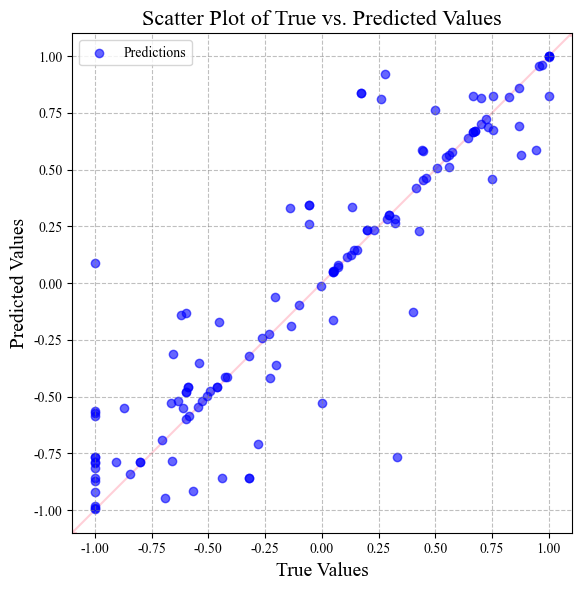

In [34]:
# 保存结果到CSV
results_df = pd.DataFrame({
    'Fold': [i+1 for i in range(5)],
    'RMSE': rmse_scores,
    'MAE': mae_scores,
    'MAPE': mape_scores,
    'R2': r2_scores,
    'Fold Time': fold_times,  # 每个fold总时间
})

# 计算平均值和标准差
results_df.loc['Mean'] = [None, rmse_mean, mae_mean, mape_mean, r2_mean, average_fold_time]
results_df.loc['Std'] = [None, rmse_std, mae_std, mape_std, r2_std, None]

# 保存到CSV
results_df.to_csv('GAT-LSTM_validation_results.csv', index=True)

print("Results saved to 'GAT-LSTM_validation_results.csv'.")

Results saved to 'GAT-LSTM_validation_results.csv'.
